In [2]:
import gzip
import utils as ut
import numpy as np
import pickle as pkl

# Fix warnings
# https://stackoverflow.com/questions/76246578/module-numpy-has-no-attribute-warnings
# USED FOR PYCLUSTER!
import warnings
np.warnings = warnings

# SET SEED
# CHANGE THIS CAN CHANGE THE RESULTS!
seed = 23

/home/davide/anaconda3/envs/ISPR/lib/python3.12/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


# Cyclist cluster - XMeans
### K = 6 (auto)
### FEATURES: 'avg_position_profile_1', 'avg_position_profile_2', 'avg_position_profile_3', 'avg_position_profile_4', 'avg_position_profile_5'


Using X-means provides a more flexible and dynamic clustering approach, identifying more distinct groups that better reflect the variability in cyclists’ performance across different race profiles. This method enables a clearer distinction between high-performing, mid-range, and underperforming cyclists, as well as those with inconsistent results.

 - Cluster 4:
   - Cyclists with the best average positions, consistently performing well across all race profiles. These clusters likely represent elite performers.
 - Clusters 0, 2, 3, 5:
	- Cyclists with average positions concentrated in the middle range. These groups show moderate consistency but lack standout results in specific race types.
 - Cluster 1:
	- Cyclists with poorer average positions, especially noticeable in the more challenging profiles (high mountains and uphill finishes). These clusters capture lower-performing cyclists.

data:                  cyclist  birth_year        bmi  average_cyclist_age  \
0       aad-van-den-hoek        1951  22.256908            28.500000   
1             aaron-gate        1990  21.672110            27.032258   
2            aaron-kemps        1983  22.282592            23.103448   
3            aaron-olsen        1978  21.799308            28.500000   
4       aaron-van-poucke        1998  21.705129            23.000000   
...                  ...         ...        ...                  ...   
4472       zdenek-stybar        1985  20.305175            32.174033   
4473       zenon-jaskula        1962  22.694019            32.725000   
4474  zhandos-bizhigitov        1991  20.616319            26.575758   
4475       zico-waeytens        1991  20.679012            24.785714   
4476     zoran-klemencic        1976  20.830818            25.984375   

      adjusted_points  scaled_adjusted_points  average_position  \
0          593.360509             3585.449737         80.60869

Assigning clusters: 100%|██████████| 6/6 [00:00<00:00, 94254.02it/s]


<Figure size 1200x800 with 0 Axes>

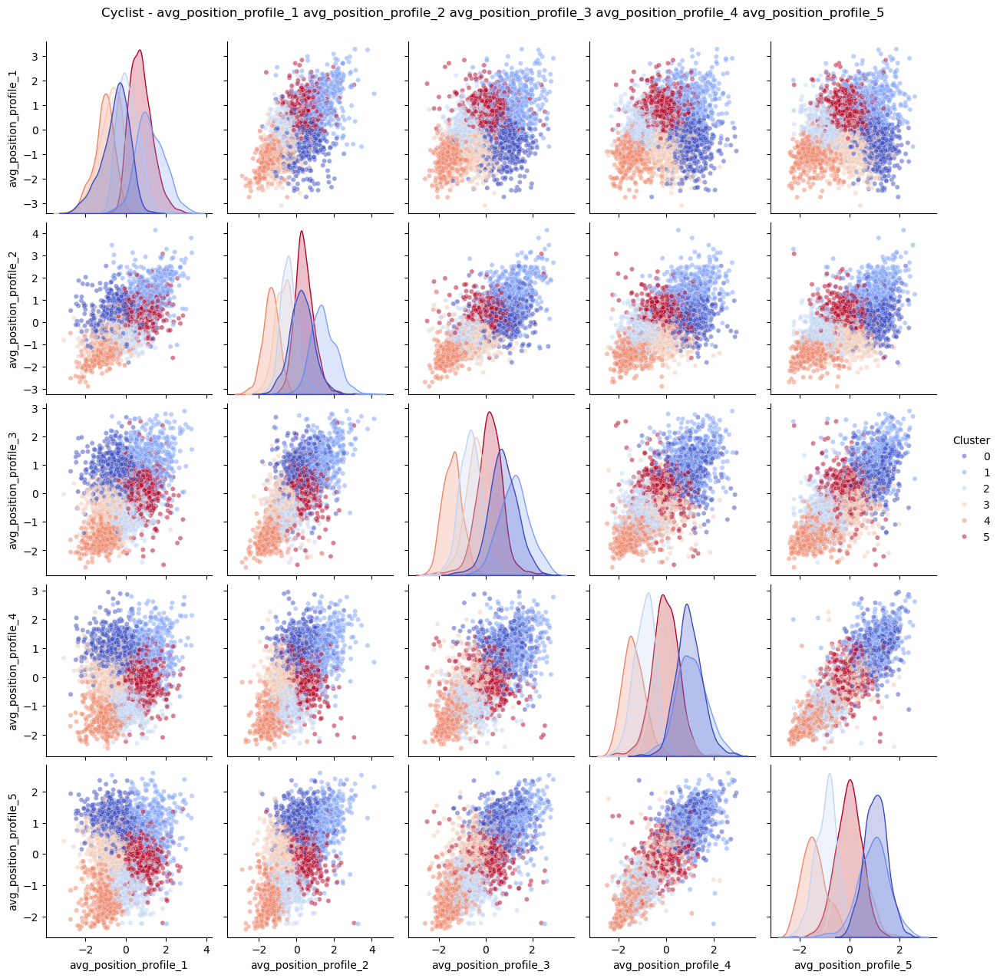

In [3]:
# Load the dataset
with gzip.open('../dataset/cyclist_nf.pkl', 'r') as file:
    cyclists = pkl.load(file)
# Features
features = ['avg_position_profile_1', 'avg_position_profile_2', 'avg_position_profile_3', 'avg_position_profile_4', 'avg_position_profile_5']
ut.clustering_X_means(cyclists, features, 10, 'Cyclist', False, False, seed=seed)

# Cyclist cluster - XMeans
### K = 2 (auto)
### FEATURES: 'bmi', 'average_cyclist_age', 'position_std', 'points_std'

The X-means algorithm identified 2 clear clusters:
  - Cluster(Orange): Younger, more consistent cyclists with steady results.
  - Cluster (Blue): Older cyclists with greater variability in both physical attributes (BMI) and race performances.

This analysis highlights the relationship between age, physical fitness (BMI), and performance consistency, showing that younger cyclists tend to perform more reliably.

data:                  cyclist  birth_year        bmi  average_cyclist_age  \
0       aad-van-den-hoek        1951  22.256908            28.500000   
1             aaron-gate        1990  21.672110            27.032258   
2            aaron-kemps        1983  22.282592            23.103448   
3            aaron-olsen        1978  21.799308            28.500000   
4       aaron-van-poucke        1998  21.705129            23.000000   
...                  ...         ...        ...                  ...   
4472       zdenek-stybar        1985  20.305175            32.174033   
4473       zenon-jaskula        1962  22.694019            32.725000   
4474  zhandos-bizhigitov        1991  20.616319            26.575758   
4475       zico-waeytens        1991  20.679012            24.785714   
4476     zoran-klemencic        1976  20.830818            25.984375   

      adjusted_points  scaled_adjusted_points  average_position  \
0          593.360509             3585.449737         80.60869

Assigning clusters: 100%|██████████| 2/2 [00:00<00:00, 41120.63it/s]

<Figure size 1200x800 with 0 Axes>

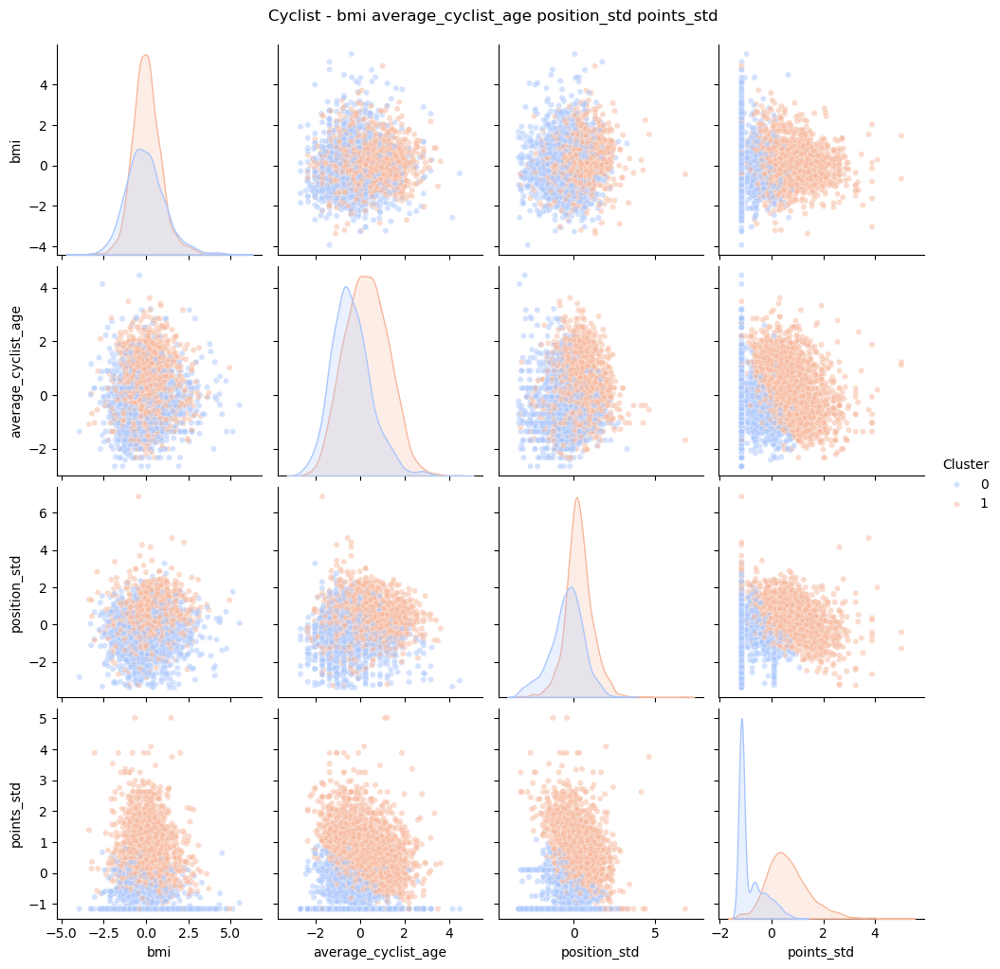

In [4]:
# Load the dataset
with gzip.open('../dataset/cyclist_nf.pkl', 'r') as file:
    cyclists = pkl.load(file)
# Features
features = ['bmi', 'average_cyclist_age', 'position_std', 'points_std']
ut.clustering_X_means(cyclists, features, 10, 'Cyclist', False, False, seed=seed)

# Cyclist cluster - XMeans
### K = 10 (auto)
### FEATURES: 'adjusted_points', 'avg_position_profile_1', 'avg_position_profile_2','avg_position_profile_3', 'avg_position_profile_4', 'avg_position_profile_5'

In this clustering analysis, the X-means algorithm was applied to identify performance patterns among cyclists using adjusted_points and average positions across five race profiles. The algorithm determined 10 clusters, revealing a detailed segmentation that highlights varying levels of performance, specialization, and consistency.

The results show that certain groups of cyclists consistently perform well across all race types, particularly in challenging terrains like mountainous and high-mountain profiles. These elite cyclists stand out with high adjusted points and excellent average positions, especially in profiles that test endurance and climbing ability. In contrast, another portion of the cyclists demonstrates solid but less exceptional results, often performing better in less demanding terrains such as flat and hilly races.

A notable distinction emerges for cyclists who exhibit greater variability in their results. Some show inconsistencies across race profiles, achieving moderate or fluctuating performances without excelling in any particular area. At the lower end, there are cyclists with lower adjusted points and weaker average positions across all race types, indicating generally poor performance.

data:                  cyclist  birth_year        bmi  average_cyclist_age  \
0       aad-van-den-hoek        1951  22.256908            28.500000   
1             aaron-gate        1990  21.672110            27.032258   
2            aaron-kemps        1983  22.282592            23.103448   
3            aaron-olsen        1978  21.799308            28.500000   
4       aaron-van-poucke        1998  21.705129            23.000000   
...                  ...         ...        ...                  ...   
4472       zdenek-stybar        1985  20.305175            32.174033   
4473       zenon-jaskula        1962  22.694019            32.725000   
4474  zhandos-bizhigitov        1991  20.616319            26.575758   
4475       zico-waeytens        1991  20.679012            24.785714   
4476     zoran-klemencic        1976  20.830818            25.984375   

      adjusted_points  scaled_adjusted_points  average_position  \
0          593.360509             3585.449737         80.60869

Assigning clusters: 100%|██████████| 10/10 [00:00<00:00, 202623.38it/s]


<Figure size 1200x800 with 0 Axes>

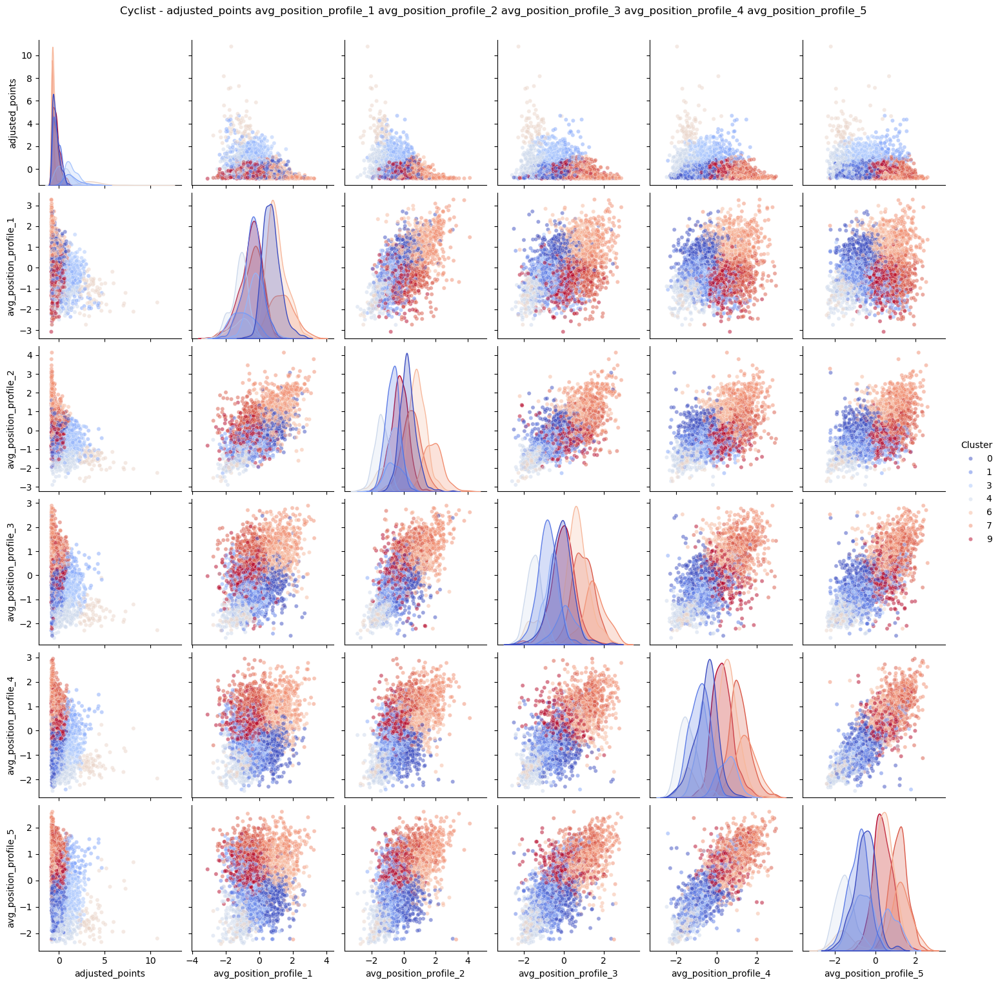

In [5]:
# Load the dataset
with gzip.open('../dataset/cyclist_nf.pkl', 'r') as file:
    cyclists = pkl.load(file)
# Features
features = ['adjusted_points', 'avg_position_profile_1', 'avg_position_profile_2','avg_position_profile_3', 'avg_position_profile_4', 'avg_position_profile_5']
ut.clustering_X_means(cyclists, features, 10, 'Cyclist', False, False, seed=seed)

# Cyclist cluster - XMeans
### K = 10 (auto)
### FEATURES: 'adjusted_points', 'position_std', 'points_std'

In this clustering analysis, the X-means algorithm was used to group cyclists based on adjusted_points, position_std and points_std, identifying 10 clusters.

The results reveal clear performance differences. Some clusters include cyclists with high adjusted_points and low variability, showing strong and consistent results. Others display greater variability, particularly in position and points, indicating fluctuating performances across races. At the lower end, there are cyclists with low adjusted_points and minimal variability, reflecting consistently weaker performances or lower participation.

Overall, the X-means clustering highlights distinct patterns of performance and consistency, separating top performers from those with inconsistent or weaker results while capturing variability in race outcomes.

data:                  cyclist  birth_year        bmi  average_cyclist_age  \
0       aad-van-den-hoek        1951  22.256908            28.500000   
1             aaron-gate        1990  21.672110            27.032258   
2            aaron-kemps        1983  22.282592            23.103448   
3            aaron-olsen        1978  21.799308            28.500000   
4       aaron-van-poucke        1998  21.705129            23.000000   
...                  ...         ...        ...                  ...   
4472       zdenek-stybar        1985  20.305175            32.174033   
4473       zenon-jaskula        1962  22.694019            32.725000   
4474  zhandos-bizhigitov        1991  20.616319            26.575758   
4475       zico-waeytens        1991  20.679012            24.785714   
4476     zoran-klemencic        1976  20.830818            25.984375   

      adjusted_points  scaled_adjusted_points  average_position  \
0          593.360509             3585.449737         80.60869

Assigning clusters: 100%|██████████| 10/10 [00:00<00:00, 171897.70it/s]


<Figure size 1200x800 with 0 Axes>

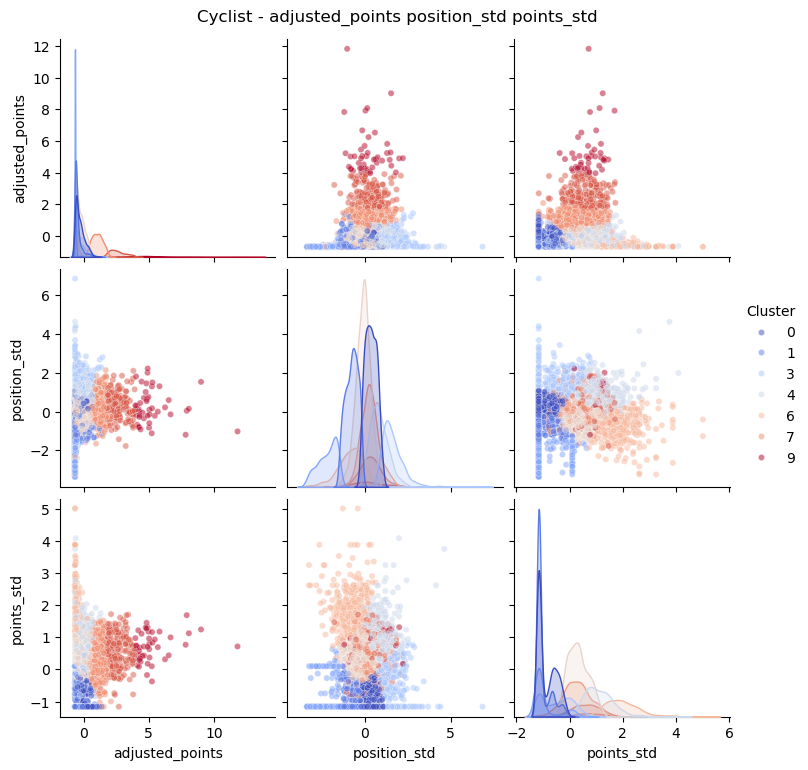

In [6]:
# Laod the dataset
with gzip.open('../dataset/cyclist_nf.pkl', 'r') as file:
    cyclists = pkl.load(file)
# Features
features = ['adjusted_points', 'position_std', 'points_std']
ut.clustering_X_means(cyclists, features, 10, 'Cyclist', False, True, seed=seed)

# Cyclist cluster - XMeans
### K = 10
### DROP ADJUSTED_POINT < 271
### FEATURES: 'adjusted_points', 'avg_position_profile_1', 'avg_position_profile_2','avg_position_profile_3', 'avg_position_profile_4', 'avg_position_profile_5'

Overall, this clustering captures a clear stratification of cyclists, distinguishing between elite, mid-level, and underperforming groups while highlighting differences in race type specialization and variability across performance metrics.
Interestingly, variability can be observed within the clusters, particularly among cyclists with mid-range adjusted points. These individuals appear to fluctuate in performance depending on race types, achieving better positions in certain profiles but struggling in others. On the other hand, clusters with low adjusted_points tend to show consistently poor results, reflecting weaker overall performances.

data:                cyclist  birth_year        bmi  average_cyclist_age  \
0     aad-van-den-hoek        1951  22.256908            28.500000   
1           aaron-gate        1990  21.672110            27.032258   
2          aaron-kemps        1983  22.282592            23.103448   
3          aaron-olsen        1978  21.799308            28.500000   
6      aart-vierhouten        1970  21.200991            33.182482   
...                ...         ...        ...                  ...   
4471   zbigniew-spruch        1965  21.461937            33.723077   
4472     zdenek-stybar        1985  20.305175            32.174033   
4473     zenon-jaskula        1962  22.694019            32.725000   
4475     zico-waeytens        1991  20.679012            24.785714   
4476   zoran-klemencic        1976  20.830818            25.984375   

      adjusted_points  scaled_adjusted_points  average_position  \
0          593.360509             3585.449737         80.608696   
1          283.7071

Assigning clusters: 100%|██████████| 10/10 [00:00<00:00, 248183.67it/s]


<Figure size 1200x800 with 0 Axes>

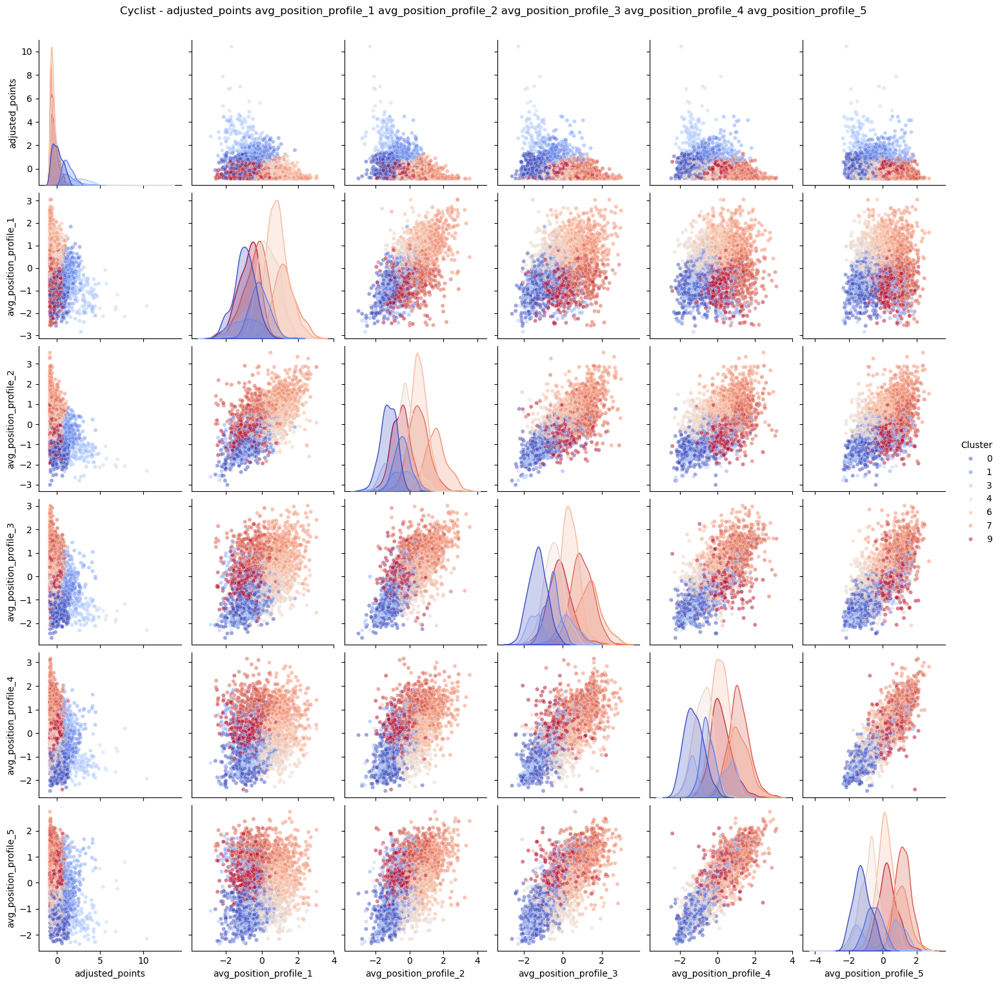

In [7]:
# Load the dataset
with gzip.open('../dataset/cyclist_nf.pkl', 'r') as file:
    cyclists = pkl.load(file)
# Drop all the cyclists with less than 271 points
cyclists = cyclists[cyclists['adjusted_points'] > 271]
# Features
features = ['adjusted_points', 'avg_position_profile_1', 'avg_position_profile_2','avg_position_profile_3', 'avg_position_profile_4', 'avg_position_profile_5']
ut.clustering_X_means(cyclists, features, 10, 'Cyclist', False, False, seed=seed, normalize_type='standard')

# Cyclist cluster - XMeans
### K = 6
### FEATURES: 'season_1_adp', 'season_2_adp','season_3_adp', 'season_4_adp', 'position_std', 'points_std', 'adjusted_points'

In this clustering analysis, the X-means algorithm was applied using seasonal adjusted points (season_1_adp, season_2_adp, season_3_adp, season_4_adp), alongside position_std, points_std, and overall adjusted_points. Compared to the previous K-means clustering, X-means identified 6 clusters, offering a more detailed segmentation of cyclist performances.

A key observation is that the top-performing group, characterized by high adjusted points across all seasons, remains largely consistent with the results from K-means. However, X-means introduces a better distinction among the low and medium-level cyclists, separating those with moderate results from those with consistently weaker performances. This finer differentiation allows for a clearer understanding of variability in performances across seasons.

By capturing these differences, X-means provides a more complex view of the cyclist groups. While the elite performers are unchanged, the algorithm excels at distinguishing between the lower and mid-level competitors, improving the overall granularity of the clustering results.

data:                  cyclist  birth_year        bmi  average_cyclist_age  \
0       aad-van-den-hoek        1951  22.256908            28.500000   
1             aaron-gate        1990  21.672110            27.032258   
2            aaron-kemps        1983  22.282592            23.103448   
3            aaron-olsen        1978  21.799308            28.500000   
4       aaron-van-poucke        1998  21.705129            23.000000   
...                  ...         ...        ...                  ...   
4472       zdenek-stybar        1985  20.305175            32.174033   
4473       zenon-jaskula        1962  22.694019            32.725000   
4474  zhandos-bizhigitov        1991  20.616319            26.575758   
4475       zico-waeytens        1991  20.679012            24.785714   
4476     zoran-klemencic        1976  20.830818            25.984375   

      adjusted_points  scaled_adjusted_points  average_position  \
0          593.360509             3585.449737         80.60869

Assigning clusters: 100%|██████████| 6/6 [00:00<00:00, 90851.35it/s]


<Figure size 1200x800 with 0 Axes>

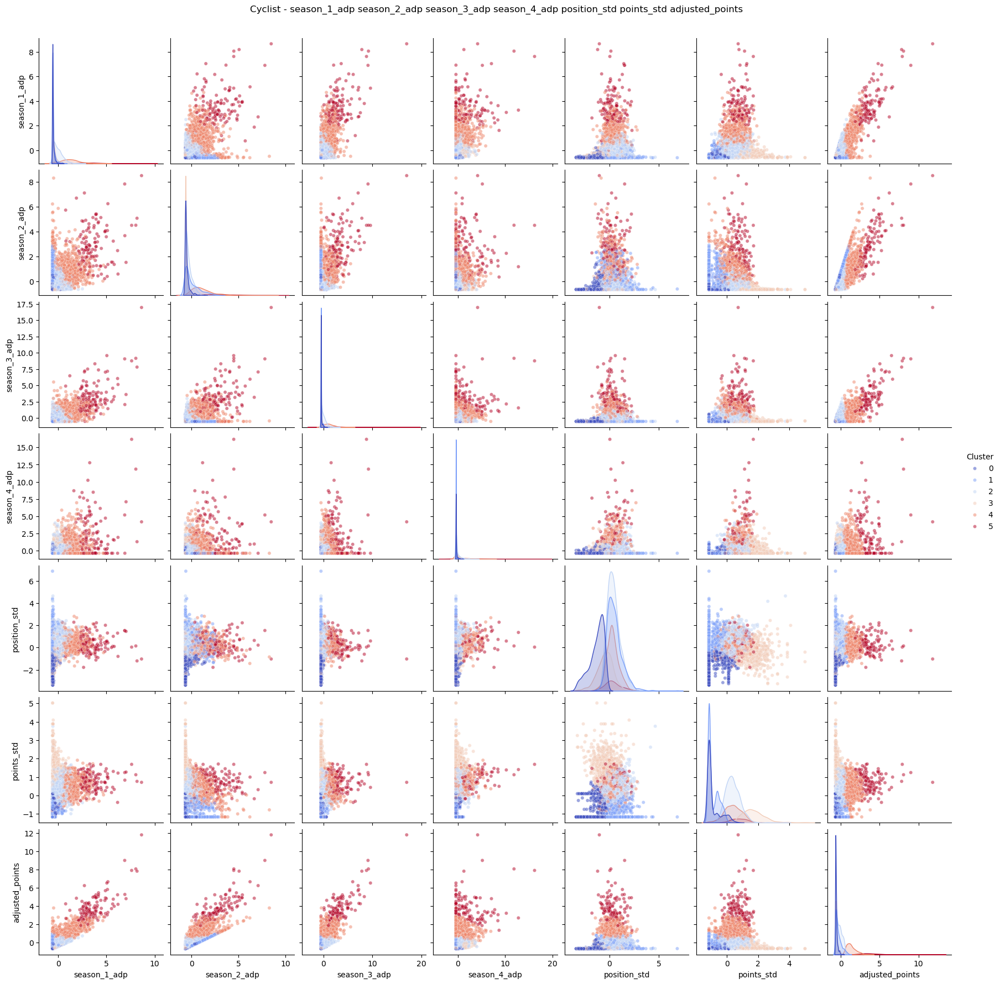

Features must be 3!


In [9]:
# Load the dataset
with gzip.open('../dataset/cyclist_nf.pkl', 'r') as file:
    cyclists = pkl.load(file)
# Features
features = ['season_1_adp', 'season_2_adp','season_3_adp', 'season_4_adp', 'position_std', 'points_std', 'adjusted_points']
ut.clustering_X_means(cyclists, features, 6, 'Cyclist', False, True, seed=seed, normalize_type='standard')